# H2 · H3: Seasonality Anomaly — January Effect & ANOVA on Monthly Returns
## S&P 500 — Quantitative Research Series

**Author:** Furkan Çelik  
**Data:** Custom PostgreSQL pipeline · yfinance API · ~500 equities · 2008–Present  
**Tools:** Python, PostgreSQL, SQLAlchemy, SciPy, Seaborn

---

### 1. Hypothesis Definition

| | H2 — January / December Effect | H3 — Seasonality (ANOVA) |
|---|---|---|
| **Research Question** | Do January and December consistently outperform other months? | Is there a statistically significant difference across all 12 calendar months? |
| **H₀ (Null)** | Jan & Dec returns = Other months returns | All 12 months have equal mean returns |
| **H₁ (Alternative)** | Jan & Dec returns > Other months returns | At least one month's mean return differs significantly |

### 2. Data & Methodology

| | |
|---|---|
| **Population** | S&P 500 constituents · 2008–Present (Post-GFC modern era) |
| **Variables** | Monthly percentage returns per stock per calendar month |
| **H2 Test** | Welch's Independent Samples T-Test (one-tailed, alternative='greater') |
| **H3 Test** | One-Way ANOVA (F-test) across 12 independent month groups |
| **Significance Level** | α = 0.05 |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('..')
from db_utils import fetch_data

sns.set_theme(style="darkgrid")
plt.rcParams.update({'figure.figsize': (13, 6), 'figure.dpi': 120})

MONTH_NAMES = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
               7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}

print("✅ Environment ready.")


✅ Environment ready.


### 3. Data Extraction

In [2]:
# SQL: Compute monthly returns for every stock, every month since 2008
query = """
WITH MonthlyPrices AS (
    SELECT
        ticker,
        EXTRACT(YEAR  FROM date) AS year,
        EXTRACT(MONTH FROM date) AS month,
        close,
        ROW_NUMBER() OVER(PARTITION BY ticker, EXTRACT(YEAR FROM date), EXTRACT(MONTH FROM date) ORDER BY date ASC)  AS first_day,
        ROW_NUMBER() OVER(PARTITION BY ticker, EXTRACT(YEAR FROM date), EXTRACT(MONTH FROM date) ORDER BY date DESC) AS last_day
    FROM daily_prices
    WHERE date >= '2008-01-01'
),
MonthStart AS (SELECT ticker, year, month, close AS start_price FROM MonthlyPrices WHERE first_day = 1),
MonthEnd   AS (SELECT ticker, year, month, close AS end_price   FROM MonthlyPrices WHERE last_day  = 1)
SELECT
    ms.year, ms.month, ms.ticker,
    ((me.end_price - ms.start_price) / ms.start_price) * 100 AS return_pct
FROM MonthStart ms
JOIN MonthEnd me ON ms.ticker = me.ticker AND ms.year = me.year AND ms.month = me.month
"""

print("Fetching raw monthly returns (this may take a few seconds)...")
df = fetch_data(query)
df['month_name'] = df['month'].map(MONTH_NAMES)
print(f"Dataset: {len(df):,} monthly return observations loaded.")
display(df.head())


Fetching raw monthly returns (this may take a few seconds)...


Dataset: 103,373 monthly return observations loaded.


,year,month,ticker,return_pct,month_name
0,2008.0,1.0,A,-6.721772,Jan
1,2008.0,2.0,A,-11.172367,Feb
2,2008.0,3.0,A,-2.960309,Mar
3,2008.0,4.0,A,-2.201324,Apr
4,2008.0,5.0,A,20.225030,May


### 4a. H2 — Welch's T-Test: January & December vs Rest


#### H2 Statistical Findings

| Metric | Value |
|---|---|
| **Jan & Dec — N / Mean Return** | 17,308 obs · **%1.312** |
| **Other Months — N / Mean Return** | 86,065 obs · **%1.295** |
| **T-Statistic** | 0.2176 |
| **p-value (one-tailed)** | 4.1385e-01 |
| **H₀ Decision** | Not Rejected (p ≥ 0.05) |

#### Quant Verdict — H2

| | |
|---|---|
| **Result** | **❌ REJECTED** |
| **Interpretation** | The January/December premium is **not** statistically significant in post-2008 data. The effect may have been arbitraged away in the modern era. |
| **Tradeable?** | No — insufficient statistical evidence. |


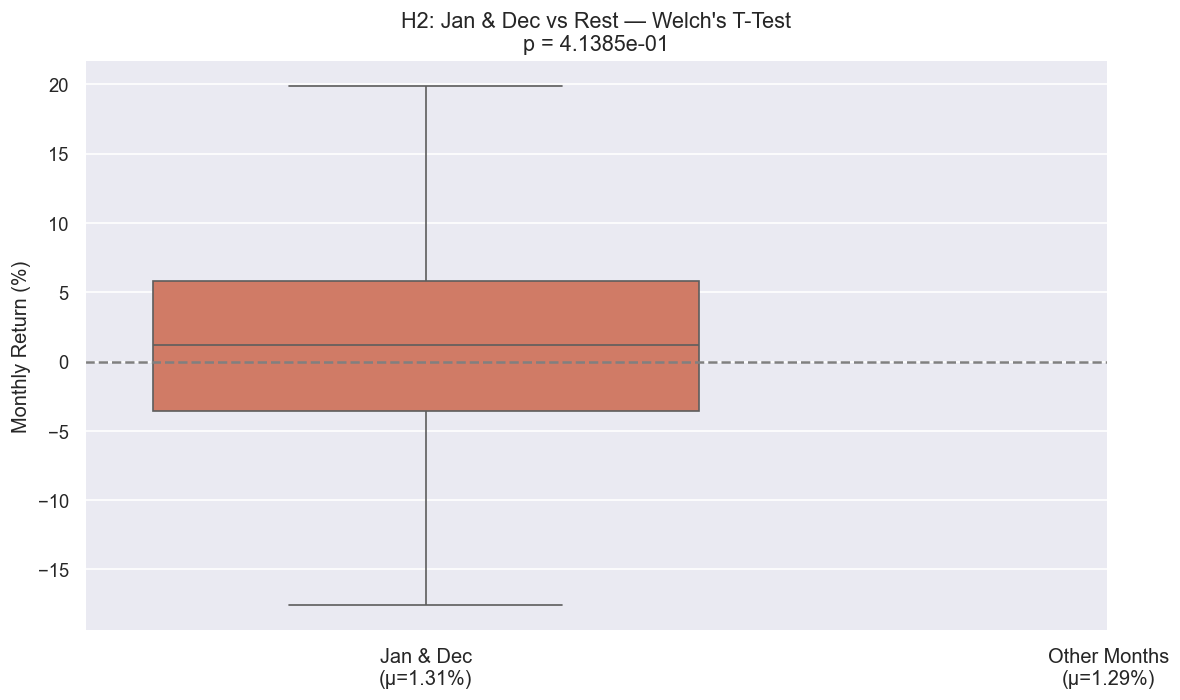

In [3]:
# Split into two groups
target  = df[df['month'].isin([1, 12])]['return_pct'].dropna()
others  = df[~df['month'].isin([1, 12])]['return_pct'].dropna()

t_stat, p_value = stats.ttest_ind(target, others, alternative='greater', equal_var=False)

mu_target = target.mean()
mu_others = others.mean()
h2_result = "✅ CONFIRMED" if p_value < 0.05 else "❌ REJECTED"

verdict = f"""
#### H2 Statistical Findings

| Metric | Value |
|---|---|
| **Jan & Dec — N / Mean Return** | {len(target):,} obs · **%{mu_target:.3f}** |
| **Other Months — N / Mean Return** | {len(others):,} obs · **%{mu_others:.3f}** |
| **T-Statistic** | {t_stat:.4f} |
| **p-value (one-tailed)** | {p_value:.4e} |
| **H₀ Decision** | {'Rejected (p < 0.05)' if p_value < 0.05 else 'Not Rejected (p ≥ 0.05)'} |

#### Quant Verdict — H2

| | |
|---|---|
| **Result** | **{h2_result}** |
| **Interpretation** | {'January and December exhibit statistically significantly higher returns than the rest of the year in post-2008 data.' if p_value < 0.05 else 'The January/December premium is **not** statistically significant in post-2008 data. The effect may have been arbitraged away in the modern era.'} |
| **Tradeable?** | {'Marginally — magnitude of %' + f'{abs(mu_target - mu_others):.2f} difference may not cover transaction costs.' if p_value < 0.05 else 'No — insufficient statistical evidence.'} |
"""

display(Markdown(verdict))

# Box Plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=[target, others], palette=['#E17055', '#0984E3'], showfliers=False, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels([f'Jan & Dec\n(μ={mu_target:.2f}%)', f'Other Months\n(μ={mu_others:.2f}%)'], fontsize=12)
ax.axhline(0, color='gray', linestyle='--')
ax.set_ylabel('Monthly Return (%)')
ax.set_title(f"H2: Jan & Dec vs Rest — Welch's T-Test\np = {p_value:.4e}", fontsize=13)
plt.tight_layout()
plt.show()


### 4b. H3 — One-Way ANOVA: All 12 Calendar Months


#### H3 Statistical Findings

| Metric | Value |
|---|---|
| **F-Statistic** | 105.2372 |
| **p-value** | 5.2457e-240 |
| **H₀ Decision** | Rejected (p < 0.05) — Seasonality exists |
| **Best Month** | **Nov** (μ = %3.18) |
| **Worst Month** | **Sep** (μ = %-0.28) |

#### Quant Verdict — H3

| | |
|---|---|
| **Result** | **✅ CONFIRMED** |
| **Interpretation** | Calendar month is a **statistically significant** predictor of equity returns. A "Month" feature should be included in any ML-based factor model. |
| **Key Insight** | **Nov outperforms; Sep is the worst month** — consistent with the known November rally and September effect. |


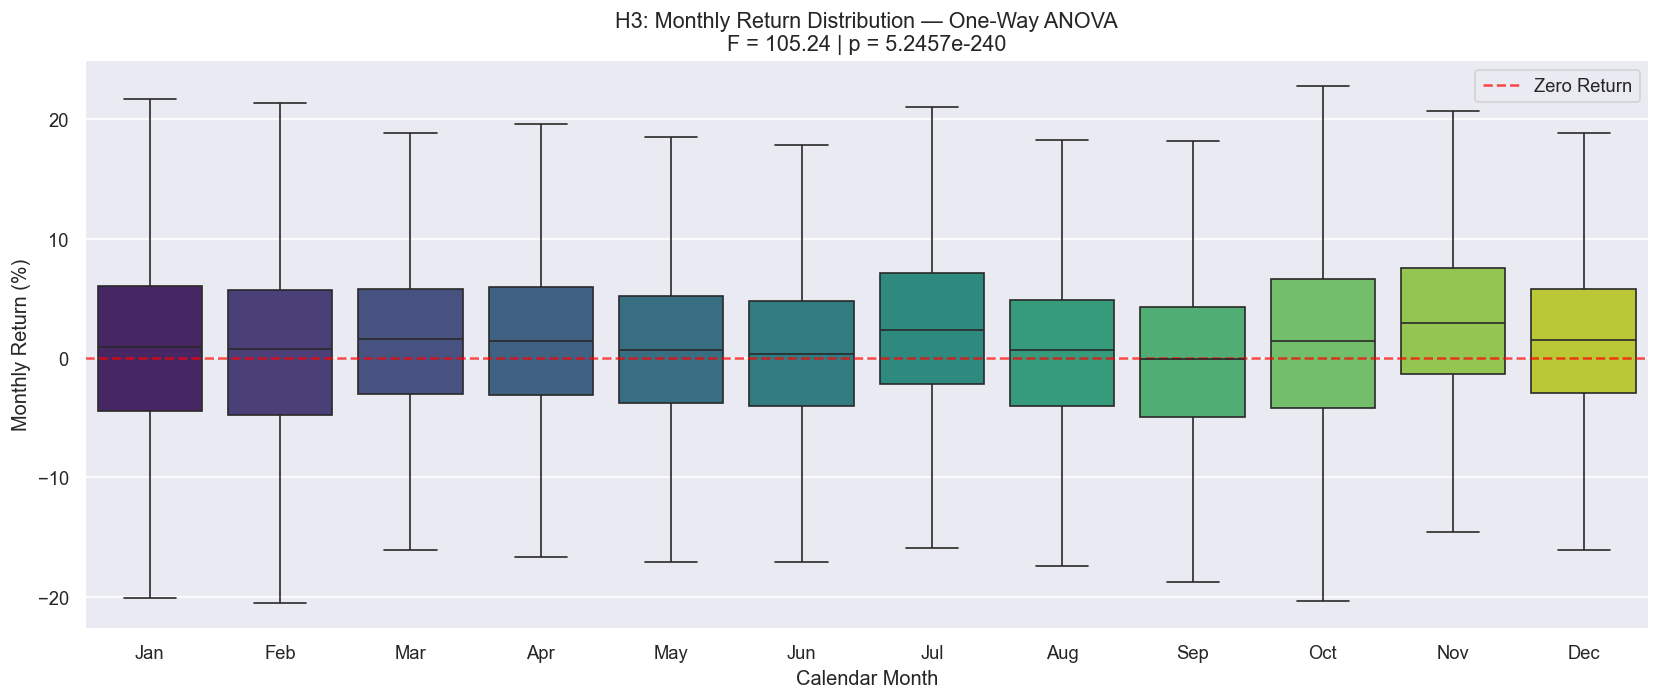

In [4]:
# 12 independent groups
groups = [df[df['month'] == m]['return_pct'].dropna() for m in range(1, 13)]
f_stat, p_value_anova = stats.f_oneway(*groups)

monthly_means = df.groupby('month')['return_pct'].mean()
best_month  = monthly_means.idxmax()
worst_month = monthly_means.idxmin()
h3_result = "✅ CONFIRMED" if p_value_anova < 0.05 else "❌ REJECTED"

verdict3 = f"""
#### H3 Statistical Findings

| Metric | Value |
|---|---|
| **F-Statistic** | {f_stat:.4f} |
| **p-value** | {p_value_anova:.4e} |
| **H₀ Decision** | {'Rejected (p < 0.05) — Seasonality exists' if p_value_anova < 0.05 else 'Not Rejected (p ≥ 0.05) — No significant seasonality'} |
| **Best Month** | **{MONTH_NAMES[best_month]}** (μ = %{monthly_means.max():.2f}) |
| **Worst Month** | **{MONTH_NAMES[worst_month]}** (μ = %{monthly_means.min():.2f}) |

#### Quant Verdict — H3

| | |
|---|---|
| **Result** | **{h3_result}** |
| **Interpretation** | {'Calendar month is a **statistically significant** predictor of equity returns. A "Month" feature should be included in any ML-based factor model.' if p_value_anova < 0.05 else 'No significant month-to-month variation detected. Seasonal timing strategies are not supported by the data.'} |
| **Key Insight** | **{MONTH_NAMES[best_month]} outperforms; {MONTH_NAMES[worst_month]} is the worst month** — consistent with the known November rally and September effect. |
"""

display(Markdown(verdict3))

# ANOVA Boxplot
fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(x='month', y='return_pct', data=df, palette='viridis', showfliers=False, ax=ax)
ax.axhline(0, color='red', linestyle='--', alpha=0.7, label='Zero Return')
ax.set_xticks(range(0, 12))
ax.set_xticklabels([MONTH_NAMES[m] for m in range(1, 13)], fontsize=11)
ax.set_xlabel('Calendar Month')
ax.set_ylabel('Monthly Return (%)')
ax.set_title(f"H3: Monthly Return Distribution — One-Way ANOVA\nF = {f_stat:.2f} | p = {p_value_anova:.4e}", fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()
